In [1]:
from pathlib import Path
import sys

current_path = Path.cwd()

if current_path.name in ["notebook", "notebooks"]:
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "utils").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Current path:", current_path)
print("Project root:", PROJECT_ROOT)
print("dataset.py exists:", (PROJECT_ROOT / "utils" / "dataset.py").exists())




Current path: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\notebook
Project root: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1
dataset.py exists: True


In [2]:
from utils.dataset import (
    get_dataloaders,
    print_dataset_info,
    get_class_counts,
)

SPLIT_ROOT = PROJECT_ROOT / "data" / "processed" / "split_images"

print("Split root:", SPLIT_ROOT)
print("Split root exists:", SPLIT_ROOT.exists())
print("Train exists:", (SPLIT_ROOT / "train").exists())
print("Val exists:", (SPLIT_ROOT / "val").exists())
print("Test exists:", (SPLIT_ROOT / "test").exists())

IMAGE_SIZE = 224
BATCH_SIZE = 32

train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = get_dataloaders(
    split_root=SPLIT_ROOT,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    use_augmentation=True,
)

print_dataset_info(train_dataset, val_dataset, test_dataset)

print("Train class counts:")
print(get_class_counts(train_dataset))

print("\nVal class counts:")
print(get_class_counts(val_dataset))

print("\nTest class counts:")
print(get_class_counts(test_dataset))

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels[:10])
print("Image dtype:", images.dtype)
print("Image min:", images.min().item())
print("Image max:", images.max().item())


Split root: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\data\processed\split_images
Split root exists: True
Train exists: True
Val exists: True
Test exists: True
Dataset Information
Train images: 1024
Val images:   146
Test images:  294

Class to index mapping:
{'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}

Classes:
['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']
Train class counts:
{'0Normal': 316, '1Doubtful': 308, '2Mild': 134, '3Moderate': 122, '4Severe': 144}

Val class counts:
{'0Normal': 45, '1Doubtful': 44, '2Mild': 19, '3Moderate': 18, '4Severe': 20}

Test class counts:
{'0Normal': 91, '1Doubtful': 88, '2Mild': 38, '3Moderate': 35, '4Severe': 42}
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels: tensor([3, 4, 0, 1, 0, 0, 0, 0, 3, 3])
Image dtype: torch.float32
Image min: -2.1179039478302
Image max: 2.640000104904175


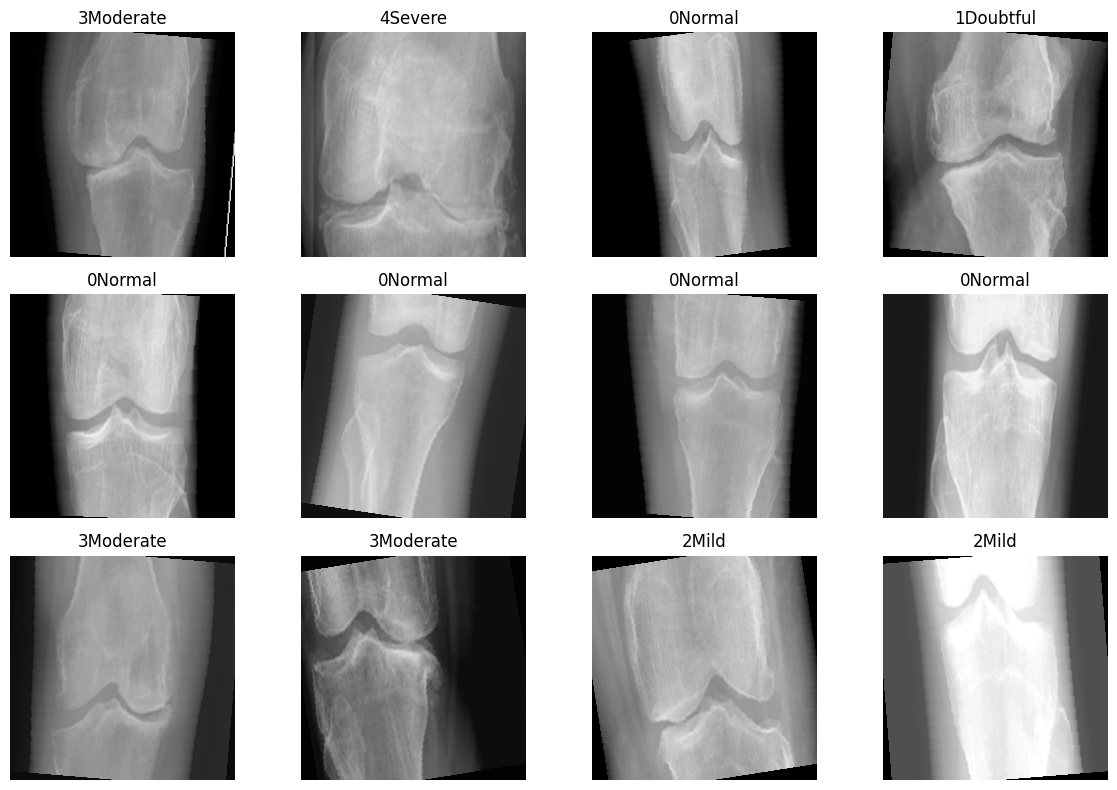

In [3]:
import matplotlib.pyplot as plt
import torch

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class_names = train_dataset.classes

def denormalize(img_tensor):
    img = img_tensor.cpu() * IMAGENET_STD + IMAGENET_MEAN
    img = torch.clamp(img, 0, 1)
    return img

plt.figure(figsize=(12, 8))

for i in range(12):
    img = denormalize(images[i])
    label = labels[i].item()

    plt.subplot(3, 4, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()
